# LIVE CODING 2: Optimización e implementación de una CNN para reconocimiento de imágenes

Este notebook está pensado para una **demo en clases**.  
La idea es recorrer un flujo realista y didáctico:

1. Cargar y explorar el dataset **CIFAR-10**
2. Entrenar una **CNN base**
3. Evaluar con:
   - accuracy
   - matriz de confusión
   - precision, recall y F1
4. Mejorar el modelo con:
   - **Data Augmentation**
   - **Dropout**
   - **Early Stopping**
5. Introducir **Transfer Learning** con un modelo preentrenado
6. Comparar resultados y analizar predicciones

> Dataset: **CIFAR-10**  
> Clases: avión, auto, pájaro, gato, ciervo, perro, rana, caballo, barco, camión

## 1. Librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## 2. Carga del dataset CIFAR-10

CIFAR-10 ya trae una división predefinida:

- **50.000 imágenes** para entrenamiento
- **10.000 imágenes** para prueba

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = [
    "avion", "auto", "pajaro", "gato", "ciervo",
    "perro", "rana", "caballo", "barco", "camion"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test : (10000, 32, 32, 3)
y_test : (10000, 1)


## 3. Exploración visual del dataset

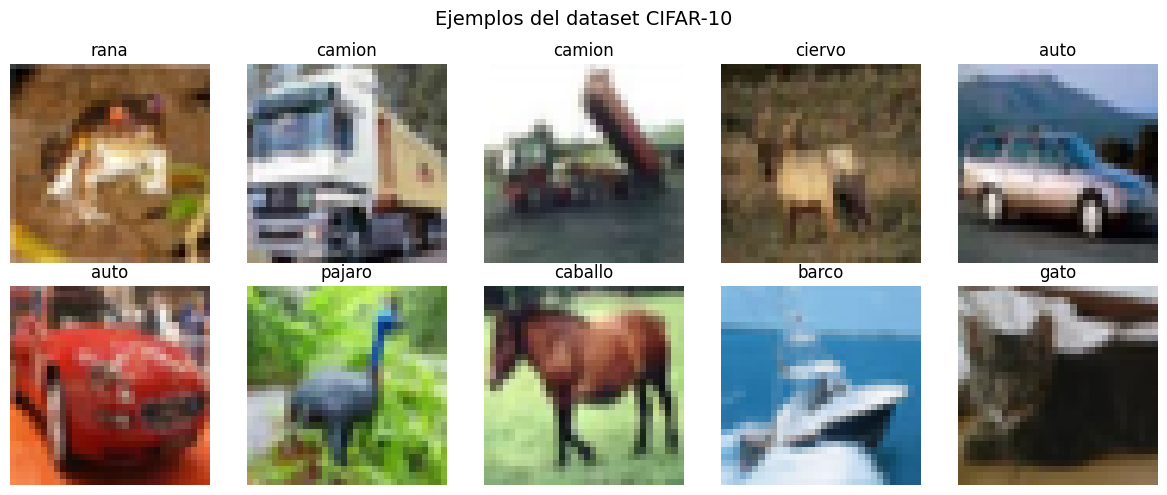

In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.suptitle("Ejemplos del dataset CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

Normalizamos los valores de píxeles al rango **[0, 1]**.

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Rango x_train:", x_train.min(), "a", x_train.max())

Rango x_train: 0.0 a 1.0


## 5. Funciones auxiliares

In [ ]:
def plot_history(history, title_prefix="Modelo"):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()


def evaluate_model(model, x_test, y_test, class_names, title="Modelo"):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = y_test.flatten()

    acc = accuracy_score(y_true, y_pred)
    print(f"\n{title} - Accuracy en test: {acc:.4f}")

    print(f"\n{title} - Reporte de clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap="Blues", fmt="d",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"{title} - Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return acc, y_pred


def show_predictions(model, x_data, y_data, class_names, n=10, title="Predicciones"):
    preds = model.predict(x_data[:n], verbose=0)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 5))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_data[i])
        real = class_names[y_data[i][0]]
        pred = class_names[pred_classes[i]]
        plt.title(f"Real: {real}\nPred: {pred}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Parte A. CNN base

## 6. Construcción de una CNN base

Esta red sigue una estructura clásica:

- capas convolucionales para extraer características
- max pooling para reducir dimensionalidad
- flatten para pasar a vector
- capas densas para clasificar

In [ ]:
def build_base_cnn():
    model = models.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    return model

base_model = build_base_cnn()
base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compilación y entrenamiento de la CNN base

In [ ]:
base_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_base = base_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 97ms/step - accuracy: 0.4216 - loss: 1.5769 - val_accuracy: 0.5392 - val_loss: 1.2785
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.5708 - loss: 1.2003 - val_accuracy: 0.6164 - val_loss: 1.0941
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.6328 - loss: 1.0402 - val_accuracy: 0.6385 - val_loss: 1.0500
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.6759 - loss: 0.9267 - val_accuracy: 0.6556 - val_loss: 0.9784
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7088 - loss: 0.8362 - val_accuracy: 0.6823 - val_loss: 0.9216
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 97ms/step - accuracy: 0.7337 - loss: 0.7599 - val_accuracy: 0.7023 - val_loss: 0.8589
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7612 - loss: 0.6844 - val_accuracy: 0.7116 - val_loss: 0.8447
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 95ms/step - accuracy: 0.7847 - loss: 0.6224 - 

## 8. Curvas de entrenamiento de la CNN base

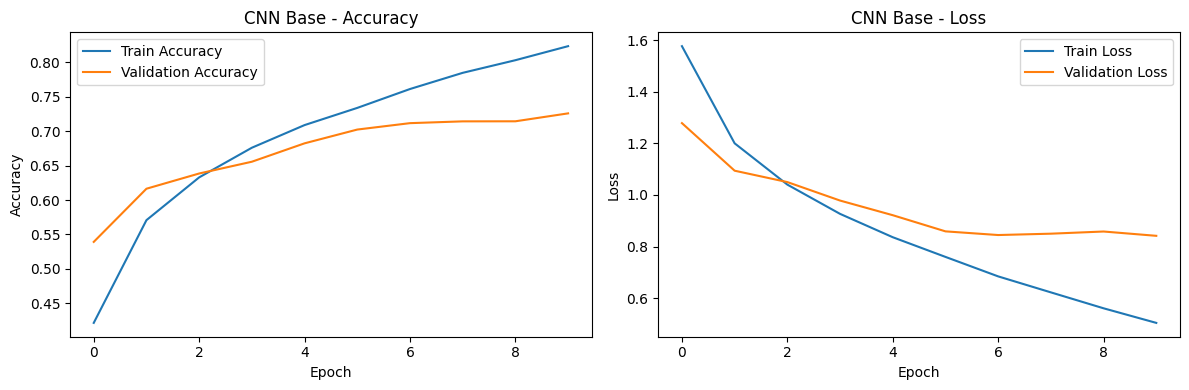

In [ ]:
plot_history(history_base, title_prefix="CNN Base")

## 9. Evaluación de la CNN base


CNN Base - Accuracy en test: 0.7238

CNN Base - Reporte de clasificación:
              precision    recall  f1-score   support

       avion       0.73      0.79      0.76      1000
        auto       0.81      0.87      0.84      1000
      pajaro       0.63      0.60      0.61      1000
        gato       0.56      0.54      0.55      1000
      ciervo       0.70      0.61      0.65      1000
       perro       0.65      0.61      0.63      1000
        rana       0.70      0.85      0.77      1000
     caballo       0.76      0.77      0.77      1000
       barco       0.86      0.78      0.82      1000
      camion       0.82      0.81      0.82      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



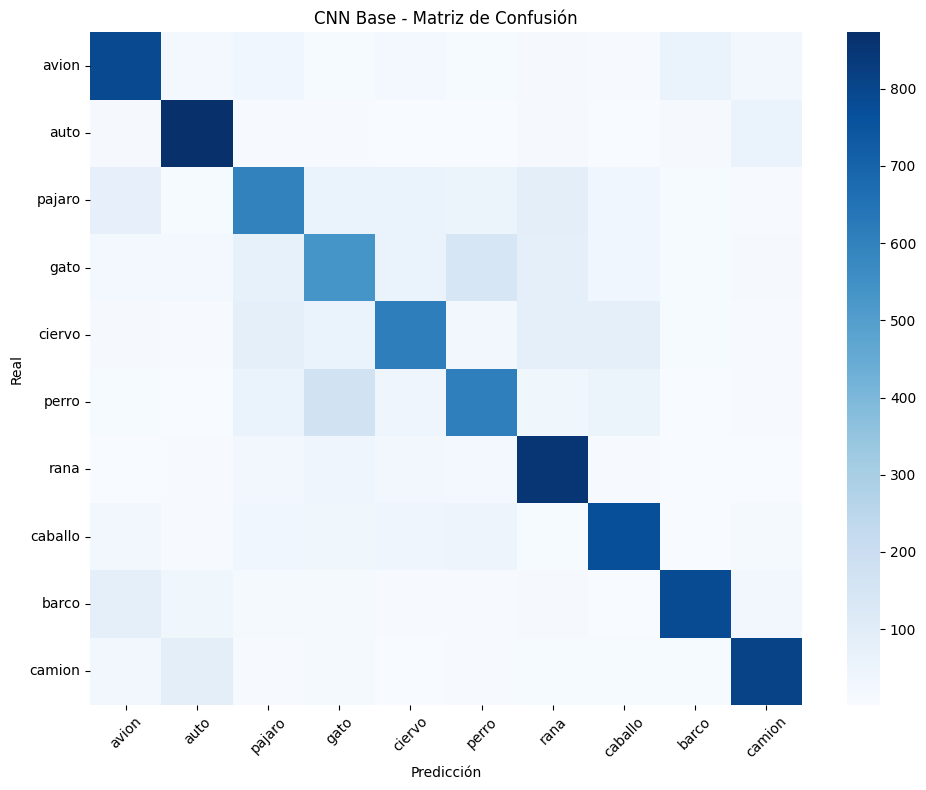

In [ ]:
acc_base, y_pred_base = evaluate_model(
    base_model, x_test, y_test, class_names, title="CNN Base"
)

## 10. Predicciones de ejemplo de la CNN base

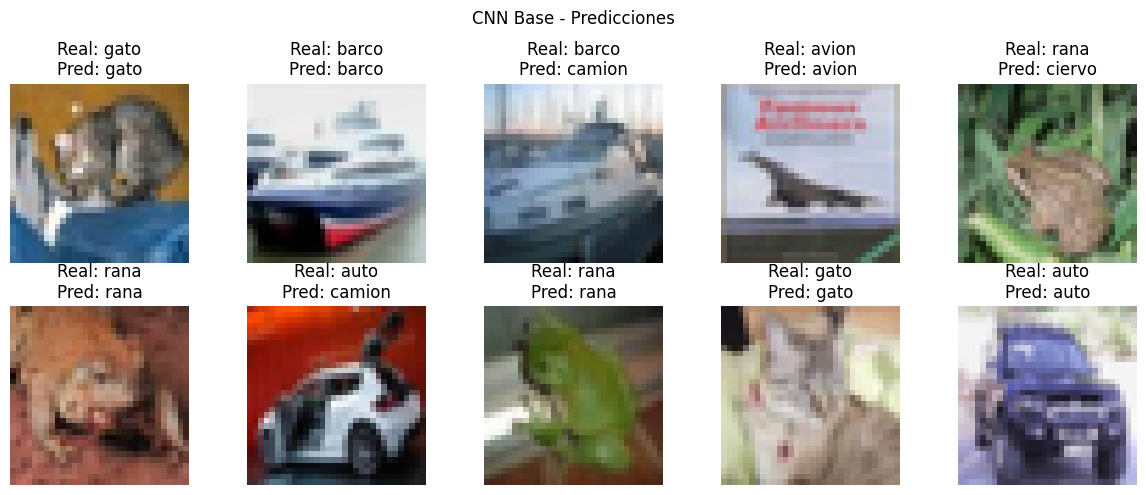

In [ ]:
show_predictions(
    base_model, x_test, y_test, class_names,
    n=10, title="CNN Base - Predicciones"
)

# Parte B. Mejora con Data Augmentation + Dropout + Early Stopping

## 11. ¿Por qué mejorar el modelo?

En una CNN base pueden aparecer problemas como:

- sobreajuste
- sensibilidad a pequeñas variaciones en la imagen
- menor capacidad de generalización

Por eso probaremos tres técnicas:

1. **Data Augmentation**
2. **Dropout**
3. **Early Stopping**

## 12. Data Augmentation

Generamos variantes artificiales de las imágenes de entrenamiento:

- rotación
- volteo horizontal
- zoom
- traslación

Esto ayuda a que el modelo sea más robusto.

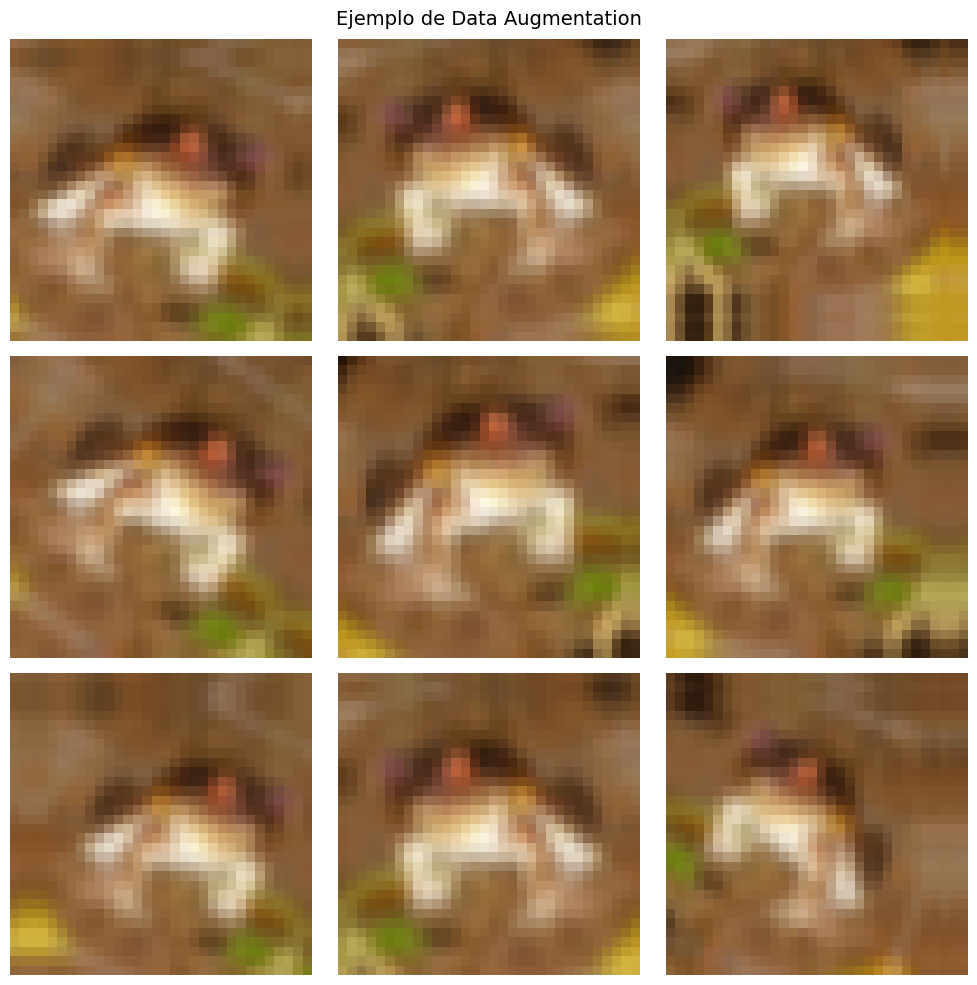

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")

sample_img = x_train[0:1]

plt.figure(figsize=(10, 10))
for i in range(9):
    augmented_img = data_augmentation(sample_img, training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_img[0])
    plt.axis("off")
plt.suptitle("Ejemplo de Data Augmentation", fontsize=14)
plt.tight_layout()
plt.show()

## 13. Early Stopping

Detendrá el entrenamiento cuando el modelo deje de mejorar en validación.

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

## 14. CNN mejorada con augmentation y dropout

In [ ]:
def build_improved_cnn():
    model = models.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),
        data_augmentation,

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(10, activation="softmax")
    ])
    return model

improved_model = build_improved_cnn()
improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## 15. Entrenamiento de la CNN mejorada

In [ ]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_improved = improved_model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 117ms/step - accuracy: 0.2982 - loss: 1.8951 - val_accuracy: 0.4330 - val_loss: 1.5464
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.4079 - loss: 1.6299 - val_accuracy: 0.4727 - val_loss: 1.4878
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 114ms/step - accuracy: 0.4561 - loss: 1.5164 - val_accuracy: 0.5214 - val_loss: 1.3708
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 116ms/step - accuracy: 0.4877 - loss: 1.4419 - val_accuracy: 0.5723 - val_loss: 1.2017
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.5044 - loss: 1.3851 - val_accuracy: 0.5509 - val_loss: 1.2766
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.5241 - loss: 1.3508 - val_accuracy: 0.5765 - val_loss: 1.2037
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.5347 - loss: 1.3114 - val_accuracy: 0.5842 - val_loss: 1.1717
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.5473 - loss: 1

## 16. Curvas de entrenamiento de la CNN mejorada

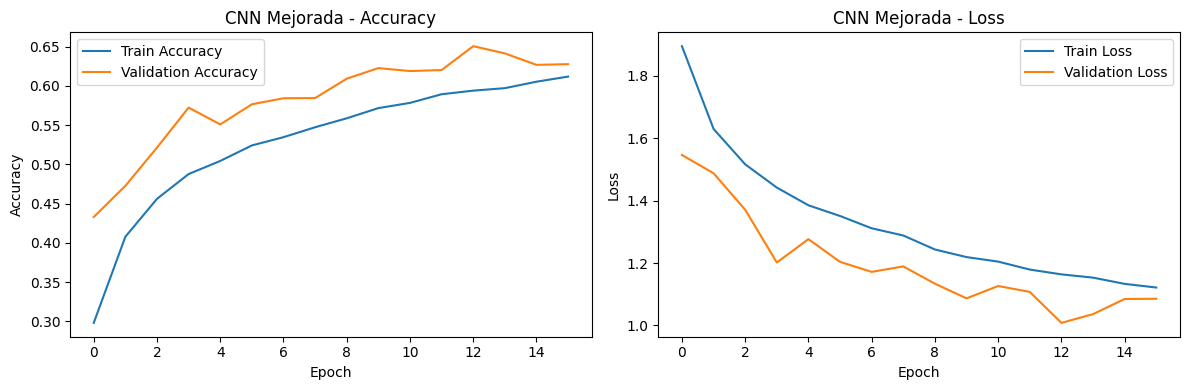

Epochs entrenadas realmente: 16


In [ ]:
plot_history(history_improved, title_prefix="CNN Mejorada")
print("Epochs entrenadas realmente:", len(history_improved.history["loss"]))

## 17. Evaluación de la CNN mejorada


CNN Mejorada - Accuracy en test: 0.6527

CNN Mejorada - Reporte de clasificación:
              precision    recall  f1-score   support

       avion       0.58      0.82      0.68      1000
        auto       0.72      0.85      0.78      1000
      pajaro       0.67      0.42      0.52      1000
        gato       0.57      0.32      0.41      1000
      ciervo       0.67      0.52      0.59      1000
       perro       0.61      0.57      0.59      1000
        rana       0.67      0.74      0.70      1000
     caballo       0.61      0.77      0.69      1000
       barco       0.81      0.74      0.77      1000
      camion       0.63      0.77      0.69      1000

    accuracy                           0.65     10000
   macro avg       0.65      0.65      0.64     10000
weighted avg       0.65      0.65      0.64     10000



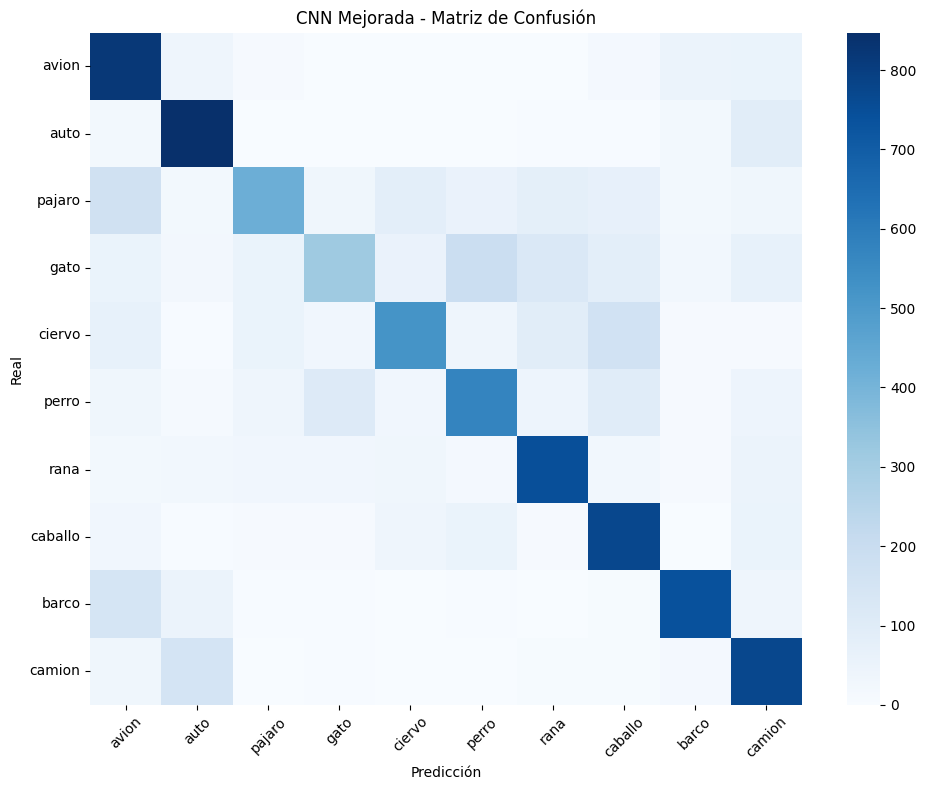

In [ ]:
acc_improved, y_pred_improved = evaluate_model(
    improved_model, x_test, y_test, class_names, title="CNN Mejorada"
)

## 18. Predicciones de ejemplo de la CNN mejorada

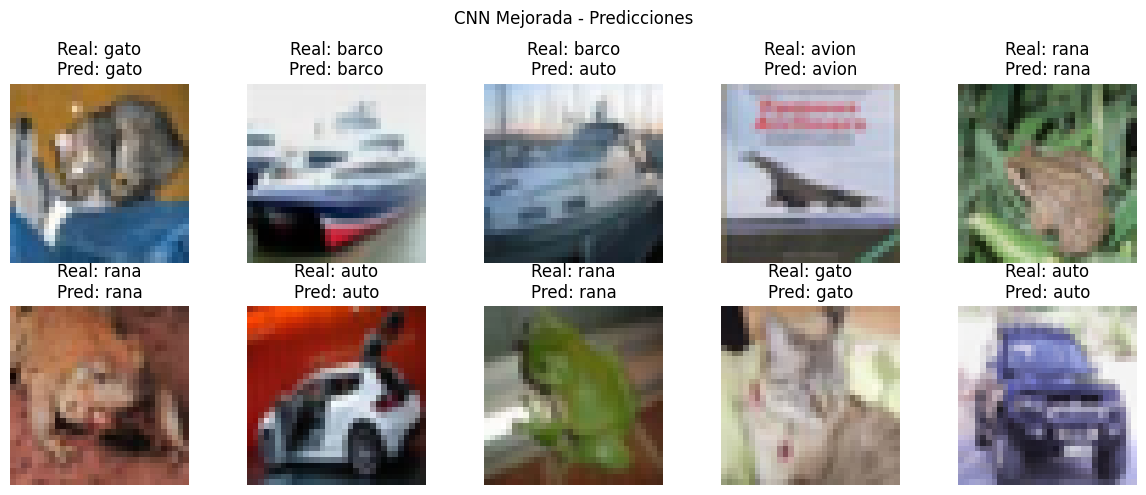

In [ ]:
show_predictions(
    improved_model, x_test, y_test, class_names,
    n=10, title="CNN Mejorada - Predicciones"
)

# Parte C. Transfer Learning con MobileNetV2

Para la demo se usará **MobileNetV2** porque suele ser más liviana y rápida que VGG16 en entornos de clase.

La lógica es la misma del transfer learning:

1. cargar modelo preentrenado
2. congelar la base
3. agregar nuevas capas
4. entrenar solo el clasificador final

## 19. Preparación de datos para MobileNetV2

MobileNetV2 espera imágenes de tamaño **96x96** o superior.  
Redimensionaremos CIFAR-10 a **96x96**.

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = 96

x_train_tl = tf.image.resize(x_train, (IMG_SIZE, IMG_SIZE)).numpy()
x_test_tl = tf.image.resize(x_test, (IMG_SIZE, IMG_SIZE)).numpy()

x_train_tl = preprocess_input(x_train_tl * 255.0)
x_test_tl = preprocess_input(x_test_tl * 255.0)

print("x_train_tl:", x_train_tl.shape)
print("x_test_tl :", x_test_tl.shape)

## 20. Carga del modelo preentrenado

In [ ]:
base_tl = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_tl.trainable = False
print("Capas entrenables en la base:", len(base_tl.trainable_variables))

## 21. Construcción del modelo con Transfer Learning

In [ ]:
transfer_model = models.Sequential([
    tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    base_tl,
    layers.GlobalAveragePooling2D(), # GlobalAveragePooling2D reduce cada mapa de características a un solo valor promedio,
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

transfer_model.summary()

## 22. Entrenamiento con Early Stopping

In [ ]:
transfer_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop_tl = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history_tl = transfer_model.fit(
    x_train_tl, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_tl],
    verbose=1
)

## 23. Curvas de entrenamiento del modelo preentrenado

In [ ]:
plot_history(history_tl, title_prefix="Transfer Learning - MobileNetV2")

## 24. Evaluación del modelo con Transfer Learning

In [ ]:
acc_tl, y_pred_tl = evaluate_model(
    transfer_model, x_test_tl, y_test, class_names, title="Transfer Learning"
)

## 25. Predicciones de ejemplo del modelo preentrenado

In [ ]:
preds_tl = transfer_model.predict(x_test_tl[:10], verbose=0)
pred_classes_tl = np.argmax(preds_tl, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i][0]]
    pred = class_names[pred_classes_tl[i]]
    plt.title(f"Real: {real}\nPred: {pred}")
    plt.axis("off")
plt.suptitle("Transfer Learning - Predicciones")
plt.tight_layout()
plt.show()

# Parte D. Comparación final

## 26. Comparación de resultados

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    "Modelo": ["CNN Base", "CNN Mejorada", "Transfer Learning"],
    "Accuracy Test": [acc_base, acc_improved, acc_tl]
})

results_df = results_df.sort_values(by="Accuracy Test", ascending=False).reset_index(drop=True)
results_df

## 27. Gráfico comparativo

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Modelo", y="Accuracy Test")
plt.ylim(0, 1)
plt.title("Comparación de Accuracy en Test")
plt.ylabel("Accuracy")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 28. Conclusiones para discutir en clase

### Ideas clave

- Una **CNN base** permite introducir el flujo completo de trabajo.
- **Data augmentation** mejora la robustez del modelo.
- **Dropout** y **Early Stopping** ayudan a controlar el sobreajuste.
- **Transfer Learning** suele entregar mejor desempeño en menos tiempo que entrenar una red profunda desde cero.
- La matriz de confusión y el reporte de clasificación ayudan a entender **dónde falla** el modelo.

### Preguntas para discusión

1. ¿Qué clases se confunden más?
2. ¿Qué técnica aportó más mejora?
3. ¿Cuándo conviene usar transfer learning?
4. ¿Qué harías para seguir mejorando el modelo?

## 29. Próximos pasos sugeridos

- probar **fine tuning**
- usar una arquitectura más grande
- incorporar más augmentations
- ajustar hiperparámetros
- comparar con otro dataset